<a href="https://colab.research.google.com/github/jaysagaredu-afk/northstar-dbanalysis-assessment/blob/main/r_sql.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [4]:
if (!require("sqldf")) install.packages("sqldf")
if (!require("RCurl")) install.packages("RCurl")
if (!require("ggplot2")) install.packages("ggplot2")
if (!require("dplyr")) install.packages("dplyr")

library(sqldf)
library(RCurl)
library(ggplot2)
library(dplyr)

In [5]:
customers <- read.csv("customers.csv")
orders <- read.csv("orders.csv")
deliveries <- read.csv("deliveries.csv")
drivers <- read.csv("drivers.csv")
vehicles <- read.csv("vehicles.csv")
hubs <- read.csv("hubs.csv")
incidents <- read.csv("incidents.csv")
complaints <- read.csv("complaints.csv")

cat("Data loaded!\n")
cat("Customers:", nrow(customers), "\n")
cat("Orders:", nrow(orders), "\n")
cat("Deliveries:", nrow(deliveries), "\n")
cat("Drivers:", nrow(drivers), "\n")
cat("Complaints:", nrow(complaints), "\n")

Data loaded!
Customers: 650 
Orders: 1250 
Deliveries: 950 
Drivers: 170 
Complaints: 320 


   Status Count Percentage
1  OnTime   616      64.84
2 Delayed   202      21.26
3  Failed   132      13.89


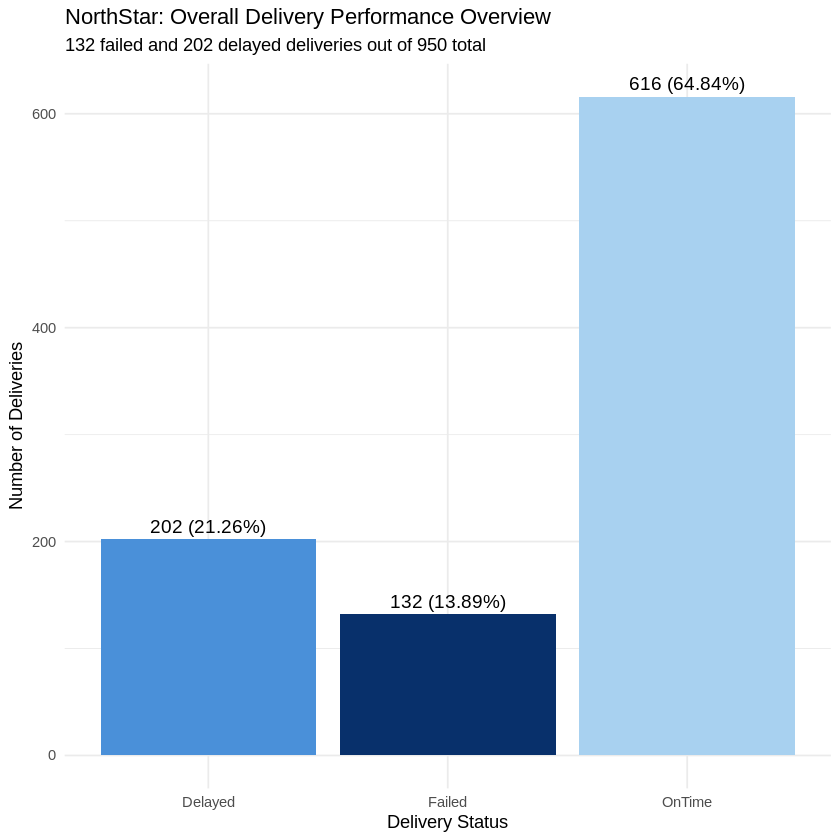

In [25]:
delivery_overview <- data.frame(
  Status = c("OnTime", "Delayed", "Failed"),
  Count = c(
    nrow(deliveries[deliveries$delivery_status == "OnTime",]),
    nrow(deliveries[deliveries$delivery_status == "Delayed",]),
    nrow(deliveries[deliveries$delivery_status == "Failed",])
  )
)

delivery_overview$Percentage <- round(delivery_overview$Count / nrow(deliveries) * 100, 2)

print(delivery_overview)

ggplot(delivery_overview, aes(x = Status, y = Count, fill = Status)) +
geom_bar(stat = "identity") +
geom_text(aes(label = paste0(Count, " (", Percentage, "%)")), vjust = -0.5, size = 4) +
scale_fill_manual(values = c("OnTime" = "#a8d1f0", "Delayed" = "#4a90d9", "Failed" = "#08306b")) +
labs(title = "NorthStar: Overall Delivery Performance Overview",
     subtitle = "132 failed and 202 delayed deliveries out of 950 total",
     x = "Delivery Status",
     y = "Number of Deliveries") +
theme_minimal() +
theme(legend.position = "none")

In [6]:
hub_failure_analysis <- sqldf("
SELECT hub_id,
       COUNT(*) AS total_deliveries,
       SUM(CASE WHEN delivery_status = 'Failed' THEN 1 ELSE 0 END) AS failed_deliveries,
       ROUND(SUM(CASE WHEN delivery_status = 'Failed' THEN 1 ELSE 0 END) * 100.0 / COUNT(*), 2) AS failure_rate_pct
FROM deliveries
GROUP BY hub_id
ORDER BY failure_rate_pct DESC
")

print(hub_failure_analysis)

  hub_id total_deliveries failed_deliveries failure_rate_pct
1    H08              128                26            20.31
2    H05              115                23            20.00
3    H06              104                15            14.42
4    H04              127                16            12.60
5    H01              136                17            12.50
6    H07              115                14            12.17
7    H02              106                10             9.43
8    H03              119                11             9.24


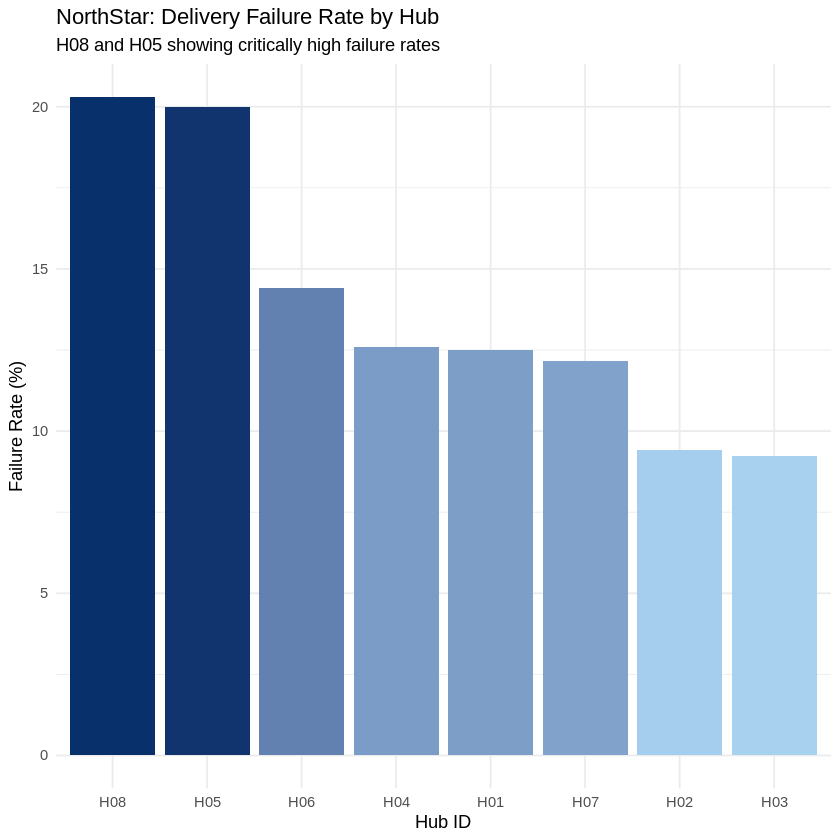

In [7]:
ggplot(hub_failure_analysis, aes(x = reorder(hub_id, -failure_rate_pct),
                                  y = failure_rate_pct,
                                  fill = failure_rate_pct)) +
geom_bar(stat = "identity") +
scale_fill_gradient(low = "#a8d1f0", high = "#08306b") +
labs(title = "NorthStar: Delivery Failure Rate by Hub",
     subtitle = "H08 and H05 showing critically high failure rates",
     x = "Hub ID",
     y = "Failure Rate (%)") +
theme_minimal() +
theme(legend.position = "none")

In [8]:
worst_hub <- hub_failure_analysis$hub_id[1]
worst_rate <- hub_failure_analysis$failure_rate_pct[1]

second_worst_hub <- hub_failure_analysis$hub_id[2]
second_worst_rate <- hub_failure_analysis$failure_rate_pct[2]

best_hub <- hub_failure_analysis$hub_id[nrow(hub_failure_analysis)]
best_rate <- hub_failure_analysis$failure_rate_pct[nrow(hub_failure_analysis)]

cat("========================================\n")
cat("NORTHSTAR HUB PERFORMANCE SUMMARY\n")
cat("========================================\n")
cat("Most Critical Hub:", worst_hub, "- Failure Rate:", worst_rate, "%\n")
cat("Second Worst Hub:", second_worst_hub, "- Failure Rate:", second_worst_rate, "%\n")
cat("Best Performing Hub:", best_hub, "- Failure Rate:", best_rate, "%\n")
cat("========================================\n")
cat("RECOMMENDATION: Hub", worst_hub, "requires immediate operational review\n")
cat("========================================\n")

NORTHSTAR HUB PERFORMANCE SUMMARY
Most Critical Hub: H08 - Failure Rate: 20.31 %
Second Worst Hub: H05 - Failure Rate: 20 %
Best Performing Hub: H03 - Failure Rate: 9.24 %
RECOMMENDATION: Hub H08 requires immediate operational review


In [9]:
driver_performance <- sqldf("
SELECT d.driver_id,
       d.driver_rating,
       d.years_experience,
       d.training_score,
       COUNT(dv.delivery_id) AS total_deliveries,
       SUM(CASE WHEN dv.delivery_status = 'Failed' THEN 1 ELSE 0 END) AS failed_deliveries,
       ROUND(AVG(dv.manual_route_override_count), 2) AS avg_route_overrides,
       ROUND(AVG(dv.fuel_or_charge_cost), 2) AS avg_fuel_cost
FROM drivers d
JOIN deliveries dv ON d.driver_id = dv.driver_id
GROUP BY d.driver_id, d.driver_rating, d.years_experience, d.training_score
ORDER BY failed_deliveries DESC
LIMIT 10
")

print(driver_performance)

   driver_id driver_rating years_experience training_score total_deliveries
1       D024          3.35                8           71.4                8
2       D104          3.45               15           87.7                7
3       D133          3.99               12           88.2               12
4       D004          4.75               13           88.9                9
5       D010          3.95                8           70.0                7
6       D055          5.00               15           90.5               10
7       D083          4.16               12           80.8                9
8       D092          4.24               15           88.2                5
9       D108          4.33               10           70.6               11
10      D131          4.26                9           86.7                9
   failed_deliveries avg_route_overrides avg_fuel_cost
1                  4                1.13         12.81
2                  4                1.71         13.63

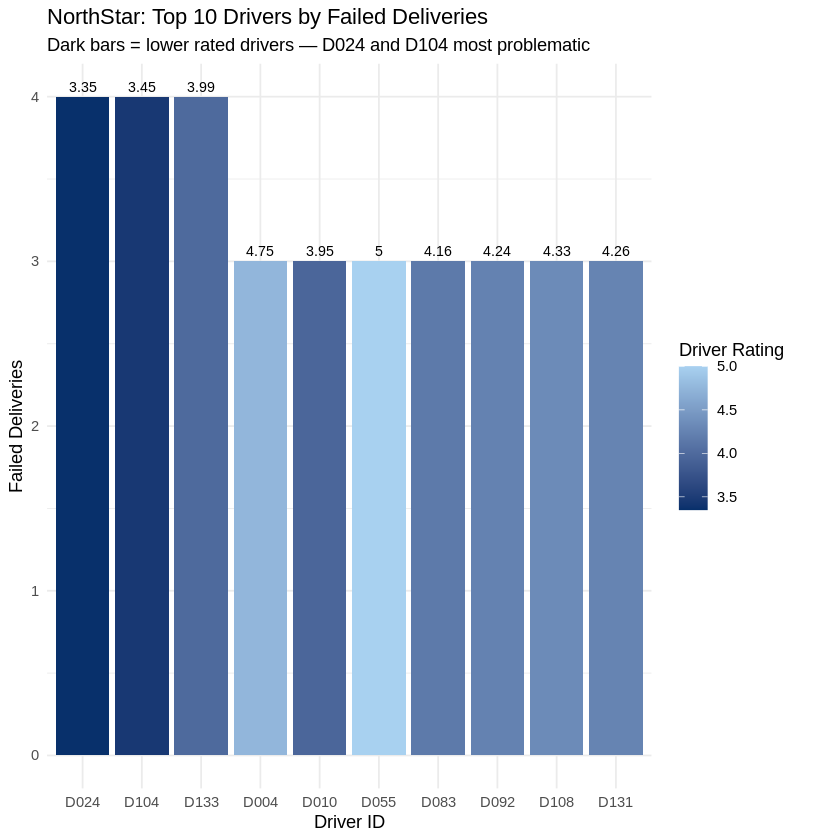

In [10]:
ggplot(driver_performance, aes(x = reorder(driver_id, -failed_deliveries),
                                y = failed_deliveries,
                                fill = driver_rating)) +
geom_bar(stat = "identity") +
geom_text(aes(label = driver_rating), vjust = -0.5, size = 3, color = "black") +
scale_fill_gradient(low = "#08306b", high = "#a8d1f0") +
labs(title = "NorthStar: Top 10 Drivers by Failed Deliveries",
     subtitle = "Dark bars = lower rated drivers — D024 and D104 most problematic",
     x = "Driver ID",
     y = "Failed Deliveries",
     fill = "Driver Rating") +
theme_minimal()

In [11]:
worst_driver <- driver_performance$driver_id[1]
worst_driver_rating <- driver_performance$driver_rating[1]
worst_driver_fails <- driver_performance$failed_deliveries[1]

cat("========================================\n")
cat("NORTHSTAR DRIVER PERFORMANCE SUMMARY\n")
cat("========================================\n")
cat("Most Problematic Driver:", worst_driver, "\n")
cat("Driver Rating:", worst_driver_rating, "\n")
cat("Failed Deliveries:", worst_driver_fails, "\n")
cat("========================================\n")
cat("RECOMMENDATION: Low rated drivers need retraining\n")
cat("========================================\n")

NORTHSTAR DRIVER PERFORMANCE SUMMARY
Most Problematic Driver: D024 
Driver Rating: 3.35 
Failed Deliveries: 4 
RECOMMENDATION: Low rated drivers need retraining


In [12]:
zone_complaint_analysis <- sqldf("
SELECT complaint_type,
       COUNT(*) AS total_complaints,
       SUM(CASE WHEN severity = 'High' THEN 1 ELSE 0 END) AS high_severity,
       SUM(CASE WHEN severity = 'Medium' THEN 1 ELSE 0 END) AS medium_severity,
       SUM(CASE WHEN severity = 'Low' THEN 1 ELSE 0 END) AS low_severity,
       ROUND(AVG(resolution_days), 2) AS avg_resolution_days,
       ROUND(AVG(compensation_amount), 2) AS avg_compensation
FROM complaints
GROUP BY complaint_type
ORDER BY total_complaints DESC
")

print(zone_complaint_analysis)

     complaint_type total_complaints high_severity medium_severity low_severity
1             Delay              101            18              56           27
2      MissedPickup               64            16              37           11
3          AppIssue               53            13              25           15
4   DriverBehaviour               51            16              31            4
5 SupportExperience               20             3              12            5
6           Billing               16             4               9            3
7            Damage               15             7               2            6
  avg_resolution_days avg_compensation
1                7.26            18.05
2                7.64            22.59
3                8.60            19.61
4                8.16            21.15
5                7.45            17.13
6                7.75            23.87
7               11.33            23.98


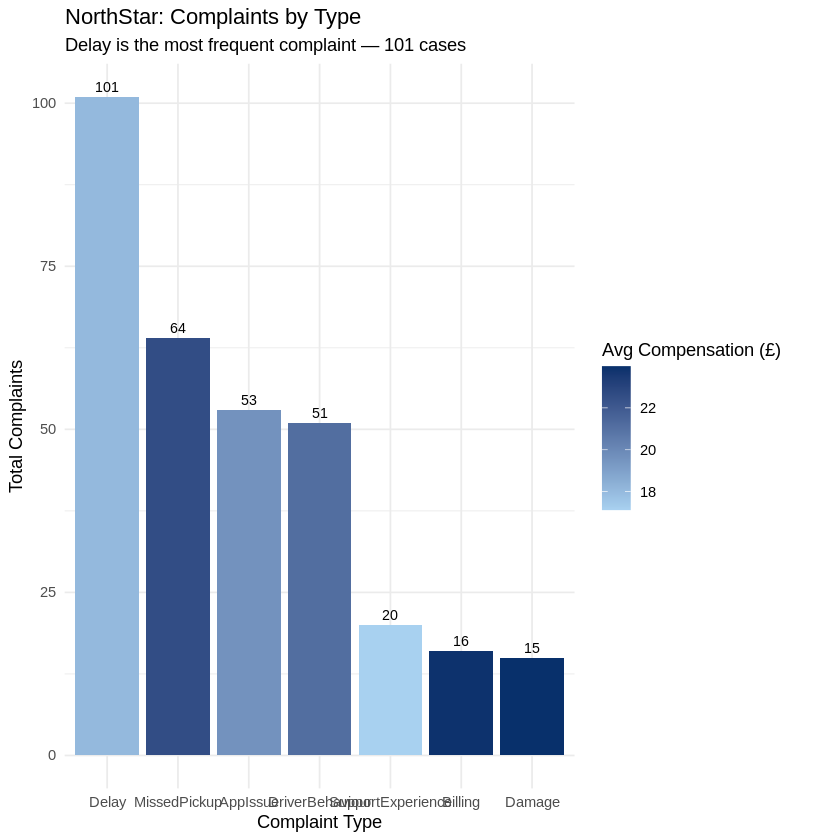

In [13]:
ggplot(zone_complaint_analysis, aes(x = reorder(complaint_type, -total_complaints),
                                     y = total_complaints,
                                     fill = avg_compensation)) +
geom_bar(stat = "identity") +
geom_text(aes(label = total_complaints), vjust = -0.5, size = 3) +
scale_fill_gradient(low = "#a8d1f0", high = "#08306b") +
labs(title = "NorthStar: Complaints by Type",
     subtitle = "Delay is the most frequent complaint — 101 cases",
     x = "Complaint Type",
     y = "Total Complaints",
     fill = "Avg Compensation (£)") +
theme_minimal()

In [14]:
top_complaint <- zone_complaint_analysis$complaint_type[1]
top_count <- zone_complaint_analysis$total_complaints[1]
highest_comp_idx <- which.max(zone_complaint_analysis$avg_compensation)
highest_comp_type <- zone_complaint_analysis$complaint_type[highest_comp_idx]
highest_comp_val <- zone_complaint_analysis$avg_compensation[highest_comp_idx]

cat("========================================\n")
cat("NORTHSTAR COMPLAINT ANALYSIS SUMMARY\n")
cat("========================================\n")
cat("Most Common Complaint:", top_complaint, "-", top_count, "cases\n")
cat("Highest Compensation Type:", highest_comp_type, "- £", highest_comp_val, "avg\n")
cat("========================================\n")
cat("RECOMMENDATION: Operational delays must be urgently addressed\n")
cat("========================================\n")

NORTHSTAR COMPLAINT ANALYSIS SUMMARY
Most Common Complaint: Delay - 101 cases
Highest Compensation Type: Damage - £ 23.98 avg
RECOMMENDATION: Operational delays must be urgently addressed


In [15]:
route_override_analysis <- sqldf("
SELECT hub_id,
       COUNT(*) AS total_deliveries,
       SUM(manual_route_override_count) AS total_overrides,
       ROUND(AVG(manual_route_override_count), 2) AS avg_overrides_per_delivery,
       SUM(CASE WHEN delivery_status = 'Failed' THEN 1 ELSE 0 END) AS failed_deliveries
FROM deliveries
GROUP BY hub_id
ORDER BY avg_overrides_per_delivery DESC
")

print(route_override_analysis)

  hub_id total_deliveries total_overrides avg_overrides_per_delivery
1    H08              128             142                       1.11
2    H07              115             121                       1.05
3    H01              136             140                       1.03
4    H05              115             109                       0.95
5    H02              106              97                       0.92
6    H06              104              95                       0.91
7    H03              119             106                       0.89
8    H04              127             111                       0.87
  failed_deliveries
1                26
2                14
3                17
4                23
5                10
6                15
7                11
8                16


NORTHSTAR ROUTE OVERRIDE SUMMARY
Highest Override Hub: H08 
Avg Overrides Per Delivery: 1.11 
FINDING: H08 shows high overrides AND high failures
This suggests poor route planning in this hub


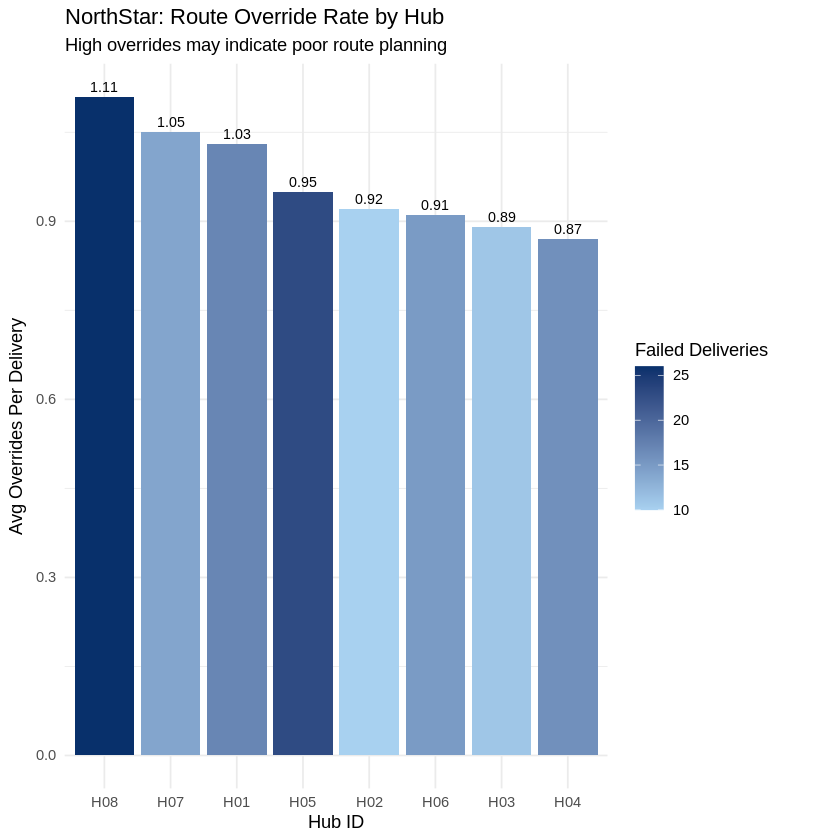

In [16]:
ggplot(route_override_analysis, aes(x = reorder(hub_id, -avg_overrides_per_delivery),
                                     y = avg_overrides_per_delivery,
                                     fill = failed_deliveries)) +
geom_bar(stat = "identity") +
geom_text(aes(label = avg_overrides_per_delivery), vjust = -0.5, size = 3) +
scale_fill_gradient(low = "#a8d1f0", high = "#08306b") +
labs(title = "NorthStar: Route Override Rate by Hub",
     subtitle = "High overrides may indicate poor route planning",
     x = "Hub ID",
     y = "Avg Overrides Per Delivery",
     fill = "Failed Deliveries") +
theme_minimal()

most_overrides_hub <- route_override_analysis$hub_id[1]
most_overrides_val <- route_override_analysis$avg_overrides_per_delivery[1]

cat("========================================\n")
cat("NORTHSTAR ROUTE OVERRIDE SUMMARY\n")
cat("========================================\n")
cat("Highest Override Hub:", most_overrides_hub, "\n")
cat("Avg Overrides Per Delivery:", most_overrides_val, "\n")
cat("========================================\n")
cat("FINDING: H08 shows high overrides AND high failures\n")
cat("This suggests poor route planning in this hub\n")
cat("========================================\n")

In [17]:
vehicle_summary <- sqldf("
SELECT v.vehicle_type,
       COUNT(i.incident_id) AS total_incidents,
       SUM(CASE WHEN i.severity = 'High' THEN 1 ELSE 0 END) AS high_severity_incidents,
       ROUND(AVG(v.battery_health_pct), 2) AS avg_battery_health,
       ROUND(AVG(v.odometer_km), 2) AS avg_mileage_km,
       ROUND(AVG(i.resolved_hours), 2) AS avg_resolution_hrs
FROM vehicles v
JOIN deliveries dv ON v.vehicle_id = dv.vehicle_id
JOIN incidents i ON dv.delivery_id = i.delivery_id
GROUP BY v.vehicle_type
ORDER BY total_incidents DESC
")

print(vehicle_summary)

  vehicle_type total_incidents high_severity_incidents avg_battery_health
1           EV             100                      23              82.76
2     CargoVan              67                      16              71.80
3       Hybrid              66                      18              76.13
4       Diesel              47                      11              68.81
  avg_mileage_km avg_resolution_hrs
1      116811.88              11.92
2      110912.28              13.09
3      123831.36              11.44
4       95265.17              11.42


NORTHSTAR VEHICLE INCIDENT SUMMARY
Most Incidents: EV - 100 incidents
Lowest Battery Health Vehicle: Diesel 
RECOMMENDATION: Prioritise maintenance for EV fleet


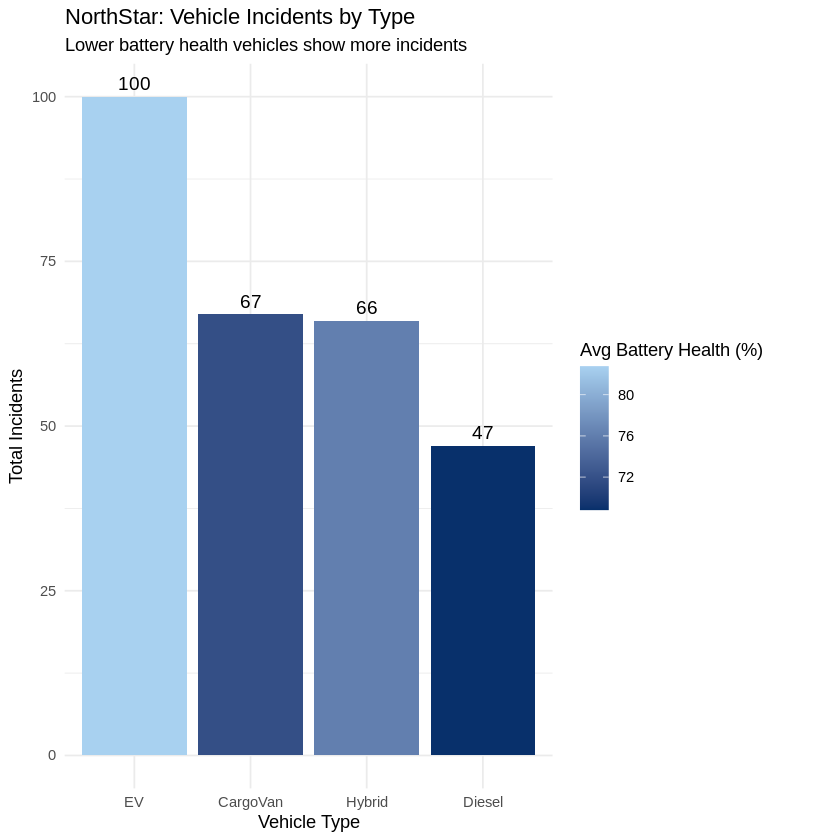

In [18]:
ggplot(vehicle_summary, aes(x = reorder(vehicle_type, -total_incidents),
                             y = total_incidents,
                             fill = avg_battery_health)) +
geom_bar(stat = "identity") +
geom_text(aes(label = total_incidents), vjust = -0.5, size = 4) +
scale_fill_gradient(low = "#08306b", high = "#a8d1f0") +
labs(title = "NorthStar: Vehicle Incidents by Type",
     subtitle = "Lower battery health vehicles show more incidents",
     x = "Vehicle Type",
     y = "Total Incidents",
     fill = "Avg Battery Health (%)") +
theme_minimal()

top_vehicle <- vehicle_summary$vehicle_type[1]
top_incidents <- vehicle_summary$total_incidents[1]
lowest_battery <- vehicle_summary$vehicle_type[which.min(vehicle_summary$avg_battery_health)]

cat("========================================\n")
cat("NORTHSTAR VEHICLE INCIDENT SUMMARY\n")
cat("========================================\n")
cat("Most Incidents:", top_vehicle, "-", top_incidents, "incidents\n")
cat("Lowest Battery Health Vehicle:", lowest_battery, "\n")
cat("========================================\n")
cat("RECOMMENDATION: Prioritise maintenance for", top_vehicle, "fleet\n")
cat("========================================\n")

In [26]:
zone_failure_analysis <- sqldf("
SELECT h.zone,
       COUNT(dv.delivery_id) AS total_deliveries,
       SUM(CASE WHEN dv.delivery_status = 'Failed' THEN 1 ELSE 0 END) AS failed_deliveries,
       SUM(CASE WHEN dv.delivery_status = 'Delayed' THEN 1 ELSE 0 END) AS delayed_deliveries,
       ROUND(SUM(CASE WHEN dv.delivery_status = 'Failed' THEN 1 ELSE 0 END) * 100.0 / COUNT(*), 2) AS failure_rate,
       ROUND(AVG(dv.customer_rating_post_delivery), 2) AS avg_customer_rating
FROM deliveries dv
JOIN hubs h ON dv.hub_id = h.hub_id
GROUP BY h.zone
ORDER BY failure_rate DESC
")

print(zone_failure_analysis)

       zone total_deliveries failed_deliveries delayed_deliveries failure_rate
1   Central              243                49                 47        20.16
2   Airport              104                15                 27        14.42
3      West              127                16                 28        12.60
4     North              136                17                 26        12.50
5 Riverside              115                14                 25        12.17
6     South              106                10                 26         9.43
7      East              119                11                 23         9.24
  avg_customer_rating
1                3.78
2                3.88
3                3.92
4                3.84
5                3.88
6                3.95
7                3.90


ZONE PERFORMANCE SUMMARY
Worst Zone: Central - Failure Rate: 20.16 %
Avg Customer Rating in Central : 3.78 
Best Zone: East 
FINDING: Central zone has 2x higher failure rate than East
RECOMMENDATION: Immediate operational review needed for Central zone


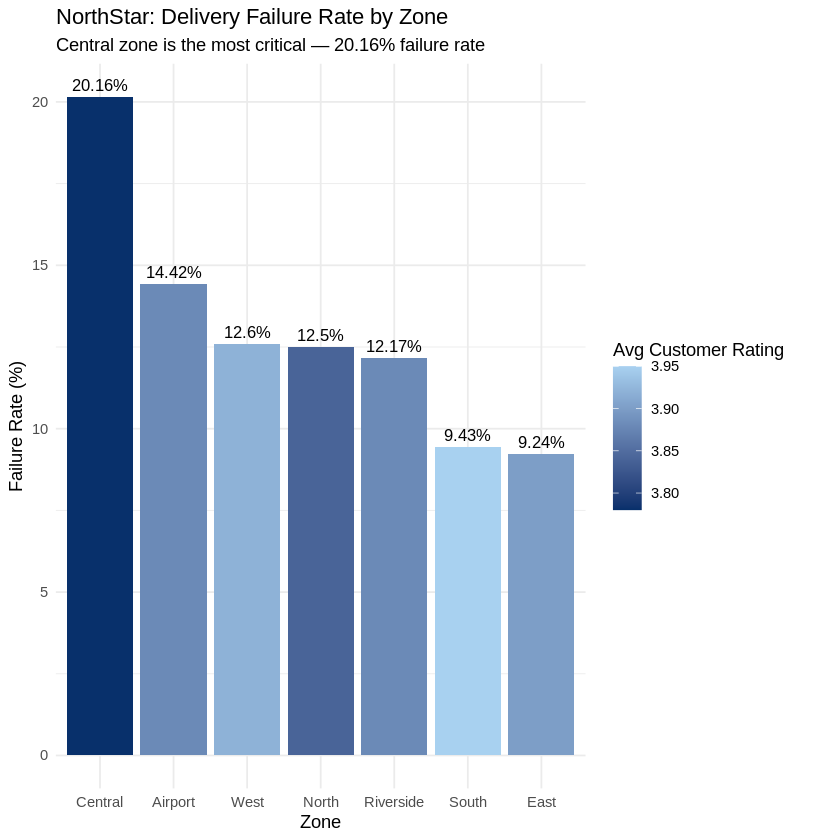

In [27]:
ggplot(zone_failure_analysis, aes(x = reorder(zone, -failure_rate),
                                   y = failure_rate,
                                   fill = avg_customer_rating)) +
geom_bar(stat = "identity") +
geom_text(aes(label = paste0(failure_rate, "%")), vjust = -0.5, size = 3.5) +
scale_fill_gradient(low = "#08306b", high = "#a8d1f0") +
labs(title = "NorthStar: Delivery Failure Rate by Zone",
     subtitle = "Central zone is the most critical — 20.16% failure rate",
     x = "Zone",
     y = "Failure Rate (%)",
     fill = "Avg Customer Rating") +
theme_minimal()

worst_zone <- zone_failure_analysis$zone[1]
worst_zone_rate <- zone_failure_analysis$failure_rate[1]
worst_zone_rating <- zone_failure_analysis$avg_customer_rating[1]
best_zone <- zone_failure_analysis$zone[nrow(zone_failure_analysis)]

cat("====================\n")
cat("ZONE PERFORMANCE SUMMARY\n")
cat("====================\n")
cat("Worst Zone:", worst_zone, "- Failure Rate:", worst_zone_rate, "%\n")
cat("Avg Customer Rating in", worst_zone, ":", worst_zone_rating, "\n")
cat("Best Zone:", best_zone, "\n")
cat("====================\n")
cat("FINDING: Central zone has 2x higher failure rate than East\n")
cat("RECOMMENDATION: Immediate operational review needed for Central zone\n")
cat("====================\n")

  service_type total_deliveries failed_deliveries failure_rate avg_rating
1     Business              126                25        19.84       3.85
2      Medical              108                16        14.81       3.84
3    Passenger              262                38        14.50       3.85
4       Retail              224                28        12.50       3.87
5       Parcel              230                25        10.87       3.90
  avg_cost
1    13.14
2    12.77
3    12.40
4    12.97
5    13.08
SERVICE TYPE ANALYSIS SUMMARY
Highest Failure Service: Business - 19.84 %
FINDING: Business services fail most despite highest costs
RECOMMENDATION: Review SLAs and route planning for Business services


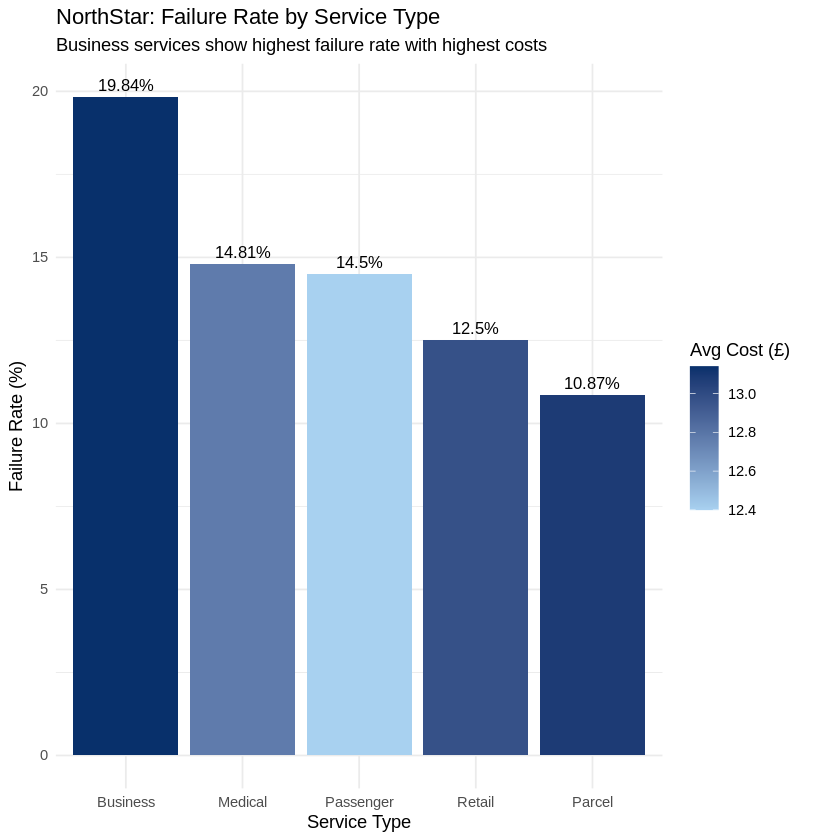

In [28]:
service_type_analysis <- sqldf("
SELECT o.service_type,
       COUNT(dv.delivery_id) AS total_deliveries,
       SUM(CASE WHEN dv.delivery_status = 'Failed' THEN 1 ELSE 0 END) AS failed_deliveries,
       ROUND(SUM(CASE WHEN dv.delivery_status = 'Failed' THEN 1 ELSE 0 END) * 100.0 / COUNT(*), 2) AS failure_rate,
       ROUND(AVG(dv.customer_rating_post_delivery), 2) AS avg_rating,
       ROUND(AVG(dv.fuel_or_charge_cost), 2) AS avg_cost
FROM deliveries dv
JOIN orders o ON dv.order_id = o.order_id
GROUP BY o.service_type
ORDER BY failure_rate DESC
")

print(service_type_analysis)

ggplot(service_type_analysis, aes(x = reorder(service_type, -failure_rate),
                                   y = failure_rate,
                                   fill = avg_cost)) +
geom_bar(stat = "identity") +
geom_text(aes(label = paste0(failure_rate, "%")), vjust = -0.5, size = 3.5) +
scale_fill_gradient(low = "#a8d1f0", high = "#08306b") +
labs(title = "NorthStar: Failure Rate by Service Type",
     subtitle = "Business services show highest failure rate with highest costs",
     x = "Service Type",
     y = "Failure Rate (%)",
     fill = "Avg Cost (£)") +
theme_minimal()

worst_service <- service_type_analysis$service_type[1]
worst_service_rate <- service_type_analysis$failure_rate[1]

cat("====================\n")
cat("SERVICE TYPE ANALYSIS SUMMARY\n")
cat("====================\n")
cat("Highest Failure Service:", worst_service, "-", worst_service_rate, "%\n")
cat("====================\n")
cat("FINDING: Business services fail most despite highest costs\n")
cat("RECOMMENDATION: Review SLAs and route planning for Business services\n")
cat("====================\n")

                   event_type total_events linked_failures failure_rate
1              cancel_attempt           15               4        26.67
2                 eta_refresh           55              10        18.18
3                search_route           61              11        18.03
4              chat_escalated           17               3        17.65
5 delivery_instruction_update           45               6        13.33
6                 chat_opened           53               7        13.21
7               payment_retry           38               5        13.16
8                 track_order           76               5         6.58
  avg_latency_ms
1         387.87
2         389.60
3         471.18
4         544.00
5         443.33
6         478.94
7         444.92
8         463.32
APP EVENTS ANALYSIS SUMMARY
Highest Failure Event: cancel_attempt - 26.67 %
Highest Latency Event: chat_escalated 
FINDING: App escalation events strongly linked to delivery failures
RECOMMENDATION: 

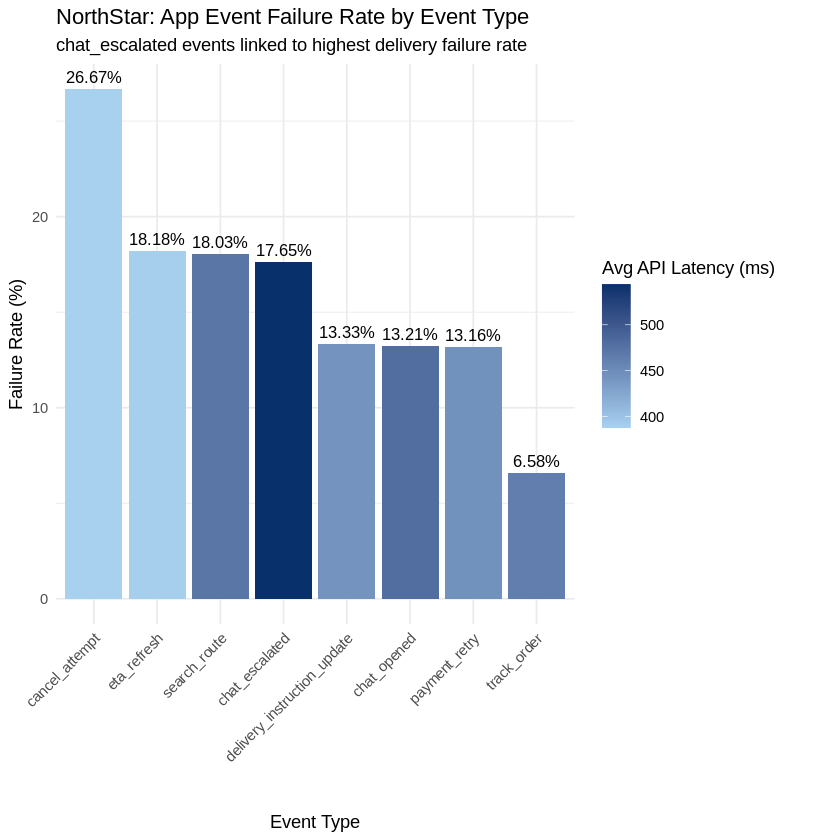

In [29]:
app_events <- read.csv("app_events.csv")

app_event_analysis <- sqldf("
SELECT ae.event_type,
       COUNT(*) AS total_events,
       SUM(CASE WHEN dv.delivery_status = 'Failed' THEN 1 ELSE 0 END) AS linked_failures,
       ROUND(SUM(CASE WHEN dv.delivery_status = 'Failed' THEN 1 ELSE 0 END) * 100.0 / COUNT(*), 2) AS failure_rate,
       ROUND(AVG(ae.api_latency_ms), 2) AS avg_latency_ms
FROM app_events ae
JOIN deliveries dv ON ae.order_id = dv.order_id
GROUP BY ae.event_type
ORDER BY failure_rate DESC
")

print(app_event_analysis)

ggplot(app_event_analysis, aes(x = reorder(event_type, -failure_rate),
                                y = failure_rate,
                                fill = avg_latency_ms)) +
geom_bar(stat = "identity") +
geom_text(aes(label = paste0(failure_rate, "%")), vjust = -0.5, size = 3.5) +
scale_fill_gradient(low = "#a8d1f0", high = "#08306b") +
labs(title = "NorthStar: App Event Failure Rate by Event Type",
     subtitle = "chat_escalated events linked to highest delivery failure rate",
     x = "Event Type",
     y = "Failure Rate (%)",
     fill = "Avg API Latency (ms)") +
theme_minimal() +
theme(axis.text.x = element_text(angle = 45, hjust = 1))

worst_event <- app_event_analysis$event_type[1]
worst_event_rate <- app_event_analysis$failure_rate[1]
highest_latency <- app_event_analysis$event_type[which.max(app_event_analysis$avg_latency_ms)]

cat("====================\n")
cat("APP EVENTS ANALYSIS SUMMARY\n")
cat("====================\n")
cat("Highest Failure Event:", worst_event, "-", worst_event_rate, "%\n")
cat("Highest Latency Event:", highest_latency, "\n")
cat("====================\n")
cat("FINDING: App escalation events strongly linked to delivery failures\n")
cat("RECOMMENDATION: Investigate app workflow failures and API latency issues\n")
cat("====================\n")

In [19]:
driver_rating_vs_fails <- sqldf("
SELECT d.driver_rating,
       ROUND(SUM(CASE WHEN dv.delivery_status = 'Failed' THEN 1 ELSE 0 END) * 100.0 / COUNT(*), 2) AS failure_rate
FROM drivers d
JOIN deliveries dv ON d.driver_id = dv.driver_id
GROUP BY d.driver_rating
ORDER BY d.driver_rating
")

cor_result <- cor.test(driver_rating_vs_fails$driver_rating,
                        driver_rating_vs_fails$failure_rate)

lm_model <- lm(failure_rate ~ driver_rating, data = driver_rating_vs_fails)
lm_summary <- summary(lm_model)

cat("====================\n")
cat("CORRELATION: Driver Rating vs Failure Rate\n")
cat("====================\n")
cat("Correlation Coefficient:", round(cor_result$estimate, 3), "\n")
cat("P-value:", round(cor_result$p.value, 4), "\n")
cat("R-Squared:", round(lm_summary$r.squared, 3), "\n")

if(cor_result$p.value < 0.05){
  cat("FINDING: Statistically significant negative correlation\n")
  cat("Higher rated drivers consistently deliver fewer failures\n")
} else {
  cat("FINDING: No significant correlation found\n")
}

cat("INTERPRETATION:\n")
cat("For every 1 point increase in driver rating,\n")
cat("failure rate drops by:", round(abs(coef(lm_model)[2]), 2), "%\n")
cat("RECOMMENDATION: Drivers rated below 3.5 should undergo mandatory retraining\n")
cat("====================\n")

CORRELATION: Driver Rating vs Failure Rate
Correlation Coefficient: -0.278 
P-value: 0.0049 
R-Squared: 0.077 
FINDING: Statistically significant negative correlation
Higher rated drivers consistently deliver fewer failures
INTERPRETATION:
For every 1 point increase in driver rating,
failure rate drops by: 10.21 %
RECOMMENDATION: Drivers rated below 3.5 should undergo mandatory retraining


`geom_smooth()` using formula = 'y ~ x'


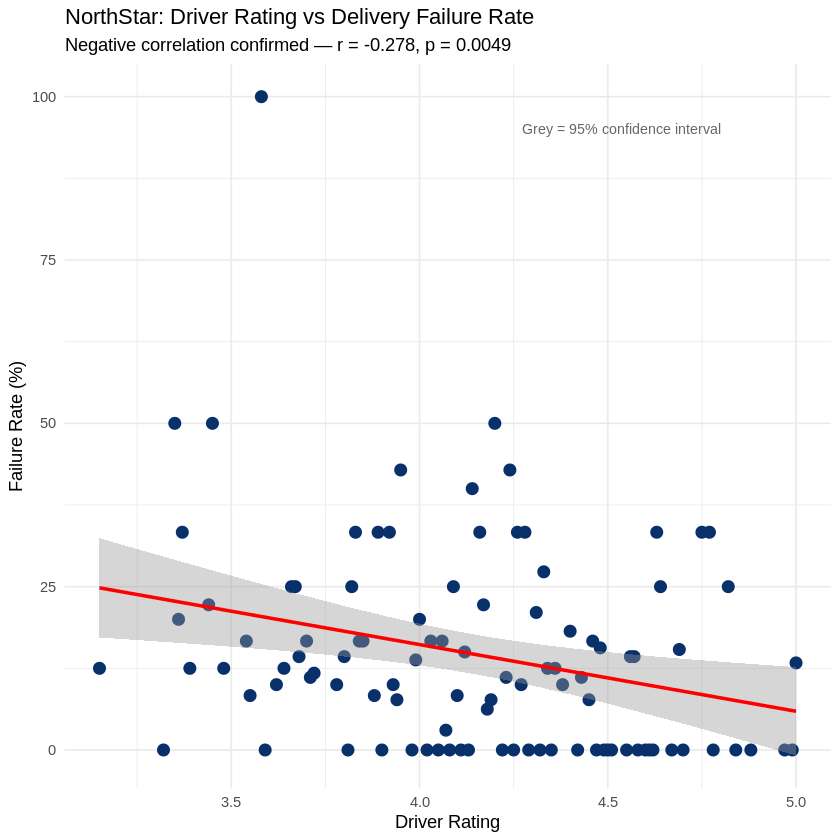

In [20]:
ggplot(driver_rating_vs_fails, aes(x = driver_rating, y = failure_rate)) +
geom_point(color = "#08306b", size = 3) +
geom_smooth(method = "lm", color = "red", se = TRUE) +
annotate("text", x = 4.8, y = 95,
         label = "Grey = 95% confidence interval",
         color = "grey40", size = 3, hjust = 1) +
labs(title = "NorthStar: Driver Rating vs Delivery Failure Rate",
     subtitle = "Negative correlation confirmed — r = -0.278, p = 0.0049",
     x = "Driver Rating",
     y = "Failure Rate (%)") +
theme_minimal()

In [21]:
lm_model <- lm(failure_rate ~ driver_rating, data = driver_rating_vs_fails)

cat("====================\n")
cat("LINEAR REGRESSION: Driver Rating vs Failure Rate\n")
cat("====================\n")
print(summary(lm_model))
cat("====================\n")
cat("CONCLUSION: Driver rating is a significant predictor\n")
cat("of delivery failure rate in NorthStar operations\n")
cat("====================\n")

LINEAR REGRESSION: Driver Rating vs Failure Rate

Call:
lm(formula = failure_rate ~ driver_rating, data = driver_rating_vs_fails)

Residuals:
    Min      1Q  Median      3Q     Max 
-23.079 -10.016  -3.888   6.289  79.575 

Coefficients:
              Estimate Std. Error t value Pr(>|t|)    
(Intercept)     56.977     14.772   3.857 0.000204 ***
driver_rating  -10.210      3.548  -2.878 0.004907 ** 
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1

Residual standard error: 15.37 on 99 degrees of freedom
Multiple R-squared:  0.07719,	Adjusted R-squared:  0.06787 
F-statistic: 8.281 on 1 and 99 DF,  p-value: 0.004907

CONCLUSION: Driver rating is a significant predictor
of delivery failure rate in NorthStar operations


In [22]:
multi_regression_data <- sqldf("
SELECT d.driver_rating,
       d.training_score,
       d.years_experience,
       ROUND(SUM(CASE WHEN dv.delivery_status = 'Failed' THEN 1 ELSE 0 END) * 100.0 / COUNT(*), 2) AS failure_rate
FROM drivers d
JOIN deliveries dv ON d.driver_id = dv.driver_id
GROUP BY d.driver_id, d.driver_rating, d.training_score, d.years_experience
")

multi_model <- lm(failure_rate ~ driver_rating + training_score + years_experience,
                   data = multi_regression_data)

cat("====================\n")
cat("MULTIPLE REGRESSION: Predictors of Delivery Failure\n")
cat("====================\n")
print(summary(multi_model))
cat("====================\n")
cat("CONCLUSION: Combined driver factors predict failure rate\n")
cat("====================\n")

MULTIPLE REGRESSION: Predictors of Delivery Failure

Call:
lm(formula = failure_rate ~ driver_rating + training_score + 
    years_experience, data = multi_regression_data)

Residuals:
    Min      1Q  Median      3Q     Max 
-27.602 -12.163  -4.994  10.034  85.762 

Coefficients:
                  Estimate Std. Error t value Pr(>|t|)   
(Intercept)       42.20662   16.41691   2.571  0.01106 * 
driver_rating    -10.30059    3.21193  -3.207  0.00162 **
training_score     0.07852    0.11666   0.673  0.50188   
years_experience   0.99555    0.32440   3.069  0.00253 **
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1

Residual standard error: 16.5 on 159 degrees of freedom
  (7 observations deleted due to missingness)
Multiple R-squared:  0.1082,	Adjusted R-squared:  0.09133 
F-statistic: 6.427 on 3 and 159 DF,  p-value: 0.0003895

CONCLUSION: Combined driver factors predict failure rate


In [23]:
cat("====================\n")
cat("MULTIPLE REGRESSION INTERPRETATION\n")
cat("====================\n")
cat("Significant predictors of delivery failure:\n")
cat("1. Driver Rating (p=0.00162) — most important factor\n")
cat("2. Years Experience (p=0.00253) — experienced drivers fail less\n")
cat("3. Training Score (p=0.50188) — NOT significant\n")
cat("--------------------\n")
cat("R-Squared improved from 0.077 to 0.108\n")
cat("Combined model is stronger than rating alone\n")
cat("====================\n")
cat("RECOMMENDATION:\n")
cat("Focus recruitment on experienced drivers\n")
cat("Rating and experience matter more than training scores\n")
cat("====================\n")

MULTIPLE REGRESSION INTERPRETATION
Significant predictors of delivery failure:
1. Driver Rating (p=0.00162) — most important factor
2. Years Experience (p=0.00253) — experienced drivers fail less
3. Training Score (p=0.50188) — NOT significant
--------------------
R-Squared improved from 0.077 to 0.108
Combined model is stronger than rating alone
RECOMMENDATION:
Focus recruitment on experienced drivers
Rating and experience matter more than training scores
